**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TICKER = "SIE.DE"

BASE_DIR = "../Data"                 # shared Data folder, one level up
OUTPUT_DIR = os.getcwd()             # outputs saved next to this notebook

PRICE_VOLUME_CSV = os.path.join(BASE_DIR, "SIE_DE_price_volume.csv")
LOG_RETURNS_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")

os.makedirs(BASE_DIR, exist_ok=True)

**Cell 2 — Download Siemens data and save to CSV**

In [2]:
if os.path.exists(PRICE_VOLUME_CSV):
    print(f"File already exists, skipping download: {PRICE_VOLUME_CSV}")
    data = pd.read_csv(PRICE_VOLUME_CSV, index_col="Date", parse_dates=True)
else:
    data = yf.download(TICKER, start="1900-01-01", progress=False)

    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)

    data = data[["Close", "Volume"]].dropna()
    data.to_csv(PRICE_VOLUME_CSV)
    print(f"Data saved to {PRICE_VOLUME_CSV}")

print(data.head())

File already exists, skipping download: ../Data/SIE_DE_price_volume.csv
               Close   Volume
Date                         
1996-11-08  9.641242  5188363
1996-11-11  9.580029  2376533
1996-11-12  9.660755  2703650
1996-11-13  9.695953  3363893
1996-11-14  9.695953        0


**Cell 3 — Compute log-returns and save to CSV**

In [3]:
if os.path.exists(LOG_RETURNS_CSV):
    print(f"File already exists, skipping computation: {LOG_RETURNS_CSV}")
    log_returns = pd.read_csv(LOG_RETURNS_CSV, index_col="Date", parse_dates=True).iloc[:, 0]
else:
    prices = pd.read_csv(PRICE_VOLUME_CSV, index_col="Date", parse_dates=True)["Close"]
    log_returns = np.log(prices / prices.shift(1)).dropna()
    log_returns.to_csv(LOG_RETURNS_CSV)
    print(f"Log-returns saved to {LOG_RETURNS_CSV}")

print(log_returns.head())
print(log_returns.tail())

File already exists, skipping computation: ../Data/SIE_DE_log_returns.csv
Date
1996-11-11   -0.006369
1996-11-12    0.008391
1996-11-13    0.003637
1996-11-14    0.000000
1996-11-15   -0.005659
Name: Close, dtype: float64
Date
2026-04-27    0.035361
2026-04-28   -0.002783
2026-04-29   -0.017675
2026-04-30    0.023234
2026-05-04    0.005922
Name: Close, dtype: float64


**Cell 4 — Reload data fresh from disk**

In [4]:
log_returns = pd.read_csv(LOG_RETURNS_CSV, index_col="Date", parse_dates=True).iloc[:, 0]

**Cell 5 — Plot log-returns, display and save**

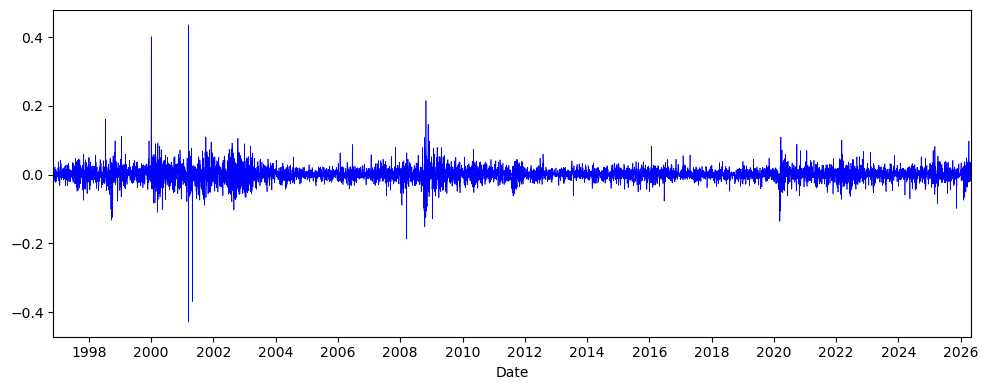

In [6]:
start_date = log_returns.index[0]
end_date = log_returns.index[-1]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(log_returns.index, log_returns, color="blue", linewidth=0.5)

ax.set_xlabel("Date")

ax.set_xlim(start_date, end_date)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(False)

fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "SIE_DE_log_returns.png"),
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()